# Notebook 05: Model Reliability & Dashboard KPIs

## Strategic Objective
Calculate the final **Reliability Metrics** for the Tsunami Dashboard. These percentages will be used as Scorecards (KPIs) in Looker Studio to provide transparency and credibility to the end user.

---

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv

# THE NUCLEAR FIX: Always work from the project root
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(CURRENT_DIR, '..')) if os.path.basename(CURRENT_DIR) == 'notebooks' else CURRENT_DIR
os.chdir(ROOT_DIR)

load_dotenv('.env')
creds_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')
if creds_path:
    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = os.path.abspath(creds_path)

project_id = os.getenv('GCP_PROJECT_ID')
dataset_id = os.getenv('GCP_DATASET_ID')
client = bigquery.Client(project=project_id)

query = f"SELECT * FROM `{project_id}.{dataset_id}.vw_looker_master_intelligence`"
df = client.query(query).to_dataframe()
df['ds'] = pd.to_datetime(df['ds'])

print(f"[SUCCESS] {len(df)} records loaded for KPI calculation.")

/Users/charlie/ai_projects/portafolio/crypto-ml-predictor/venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


[SUCCESS] 1970 records loaded for KPI calculation.


## 1. Defining the Tsunami Reliability KPI
We calculate the Accuracy for both types of Tsunamis:
1.  **Red Zone Accuracy:** How many times a Low Probability + High Volume resulted in a Price Drop.
2.  **Green Zone Accuracy:** How many times a High Probability + High Volume resulted in a Price Rise.

In [2]:
# Filter only for Tsunami events (Z-Score > 2.0)
tsunamis = df[df['ml_volume_zscore'] > 2.0].copy()

# --- RED ZONE RELIABILITY ---
red_signals = tsunamis[tsunamis['ml_probability'] < 0.4].copy()
red_hits = red_signals[red_signals['return_t30'] < 0]
red_accuracy = (len(red_hits) / len(red_signals)) * 100 if len(red_signals) > 0 else 0

# --- GREEN ZONE RELIABILITY ---
green_signals = tsunamis[tsunamis['ml_probability'] > 0.4].copy()
green_hits = green_signals[green_signals['return_t30'] > 0]
green_accuracy = (len(green_hits) / len(green_signals)) * 100 if len(green_signals) > 0 else 0

print("=== FINAL DASHBOARD KPIs ===")
print(f"Red Zone Accuracy (Exhaustion Detection): {red_accuracy:.1f}%")
print(f"Green Zone Accuracy (Momentum Detection): {green_accuracy:.1f}%")
print(f"Total Shocks Analyzed: {len(tsunamis)}")

=== FINAL DASHBOARD KPIs ===
Red Zone Accuracy (Exhaustion Detection): 73.7%
Green Zone Accuracy (Momentum Detection): 79.6%
Total Shocks Analyzed: 87


## 2. Visualizing Reliability for the Dashboard
This chart will help you explain to stakeholders why they should trust the system.

/var/folders/j9/mtv0lz0x6cb1bbktm7dcl8_m0000gn/T/ipykernel_62076/4043702434.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_data, x='Metric', y='Reliability %', palette=['#E74C3C', '#2ECC71'])


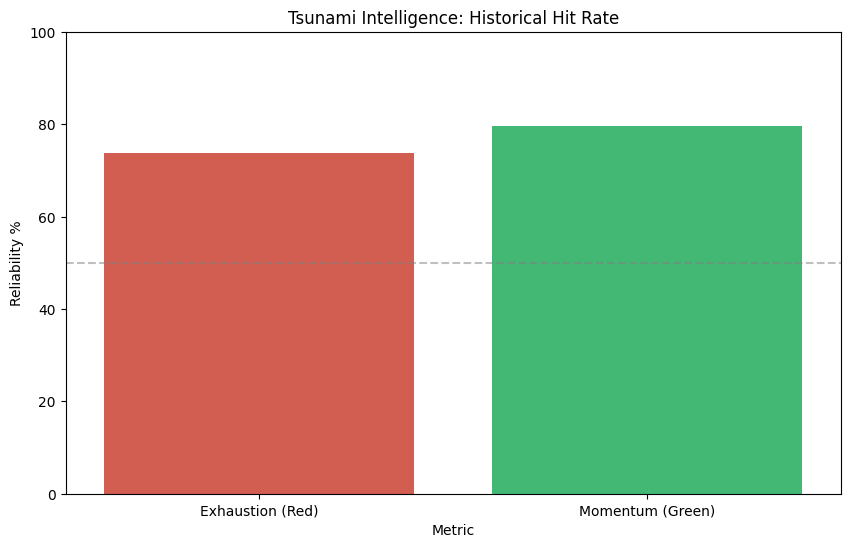

In [3]:
kpi_data = pd.DataFrame({
    'Metric': ['Exhaustion (Red)', 'Momentum (Green)'],
    'Reliability %': [red_accuracy, green_accuracy]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=kpi_data, x='Metric', y='Reliability %', palette=['#E74C3C', '#2ECC71'])
plt.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Random Guess (50%)')
plt.ylim(0, 100)
plt.title("Tsunami Intelligence: Historical Hit Rate")
plt.show()